Dataset Shape: (569, 31)

Logistic Regression Results
Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



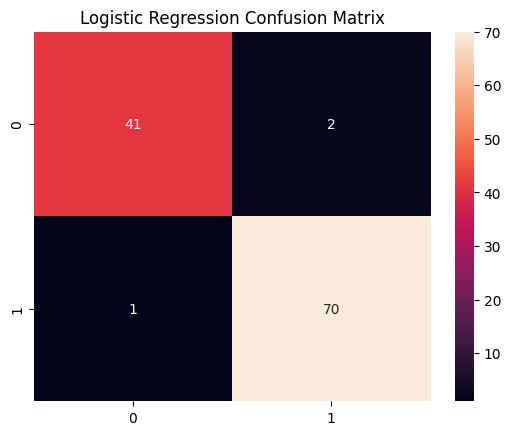


SVM Results
Accuracy: 0.9824561403508771

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



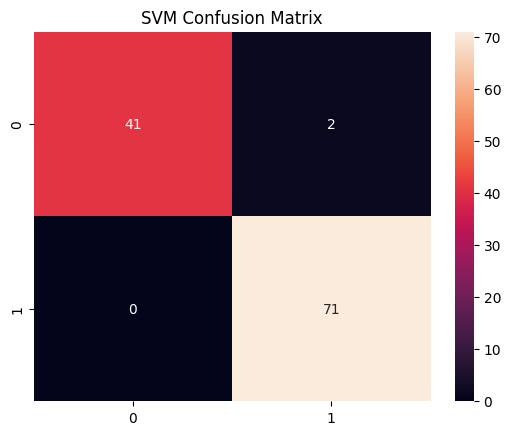


Random Forest Results
Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



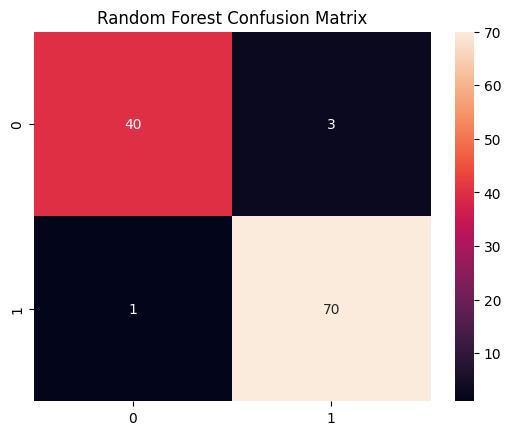

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:56:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Results
Accuracy: 0.956140350877193

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



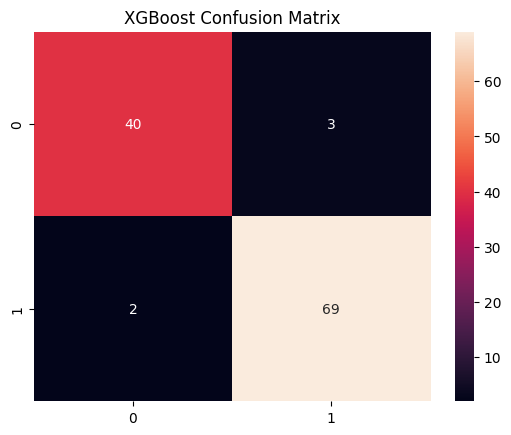


Model Comparison:
Logistic Regression: 0.9737
SVM: 0.9825
Random Forest: 0.9649
XGBoost: 0.9561


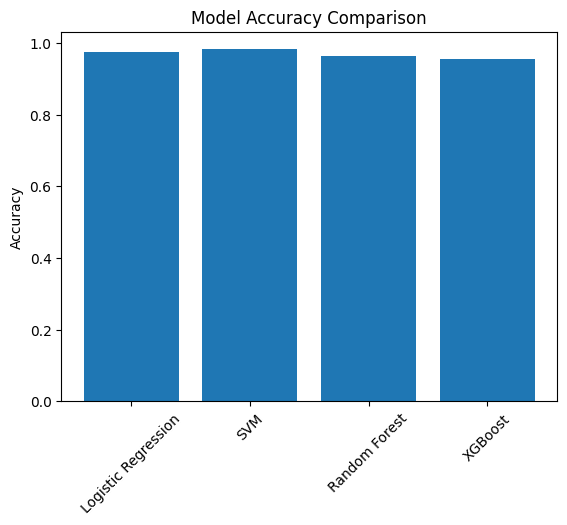

Logistic Regression Prediction: Disease
SVM Prediction: Disease
Random Forest Prediction: Disease
XGBoost Prediction: Disease


In [ ]:
# ==========================================
# 1. Install Required Libraries
# ==========================================
!pip install xgboost

# ==========================================
# 2. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ==========================================
# 3. Load Dataset
# ==========================================
# Example: Breast Cancer Dataset (built-in)
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Dataset Shape:", df.shape)
df.head()

# ==========================================
# 4. Data Preprocessing
# ==========================================
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 5. Initialize Models
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# ==========================================
# 6. Train and Evaluate Models
# ==========================================
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} Results")
    print("="*30)
    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# ==========================================
# 7. Compare Model Performance
# ==========================================
print("\nModel Comparison:")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

# Bar Plot
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# ==========================================
# 8. Make Prediction on New Data
# ==========================================
sample = X_test[0].reshape(1, -1)

for name, model in models.items():
    pred = model.predict(sample)
    print(f"{name} Prediction:", "Disease" if pred[0] == 1 else "No Disease")